In [1]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split 
from sklearn.preprocessing import LabelEncoder
from sklearn.preprocessing import StandardScaler
from sklearn.svm import SVC
from sklearn.neighbors import KNeighborsClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score
from sklearn.metrics import precision_score
from sklearn.metrics import recall_score
from sklearn.metrics import f1_score
from sklearn.metrics import confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt


df=pd.read_excel("../dataset/Smart_Internship_Recommendation_Dataset.xlsx")

In [2]:
df.head(10)

,SSC Percentage,HSC Percentage,Gender,Age,CGPA,Backlogs,Attendance,Python Skill,Java Skill,C++ Skill,...,Leadership,Teamwork,Presentation,Problem Solving,Number of Projects,Certifications Count,Internship Experience,Hackathon Participation,Research Papers,Internship Domain
0,62.0,71.0,Female,23.0,8.37,0.0,72.0,6.0,4.0,6.0,...,8.0,6.0,5.0,8.0,4.0,3.0,1.0,2.0,0.0,Cloud Engineer
1,64.0,62.0,Male,25.0,7.32,0.0,82.0,3.0,7.0,4.0,...,9.0,10.0,8.0,10.0,7.0,3.0,2.0,0.0,0.0,Cloud Engineer
2,90.0,84.0,Male,20.0,9.12,0.0,82.0,3.0,3.0,5.0,...,8.0,8.0,7.0,10.0,3.0,1.0,0.0,0.0,0.0,Cloud Engineer
3,78.0,60.0,Male,18.0,8.91,0.0,73.0,6.0,7.0,7.0,...,6.0,6.0,8.0,8.0,3.0,5.0,0.0,0.0,0.0,Cloud Engineer
4,82.0,68.0,Male,27.0,9.33,0.0,83.0,7.0,6.0,6.0,...,6.0,9.0,8.0,6.0,5.0,1.0,2.0,0.0,0.0,Cloud Engineer
5,93.0,78.0,Female,24.0,6.84,1.0,83.0,3.0,4.0,7.0,...,8.0,10.0,7.0,9.0,5.0,6.0,2.0,1.0,0.0,Cloud Engineer
6,66.0,72.0,Male,23.0,7.12,0.0,90.0,7.0,4.0,4.0,...,7.0,7.0,8.0,6.0,6.0,3.0,0.0,4.0,1.0,Cloud Engineer
7,84.0,81.0,Male,22.0,9.21,0.0,76.0,4.0,7.0,7.0,...,7.0,6.0,9.0,6.0,3.0,3.0,0.0,0.0,0.0,Cloud Engineer
8,65.0,93.0,Female,25.0,6.91,0.0,86.0,5.0,4.0,7.0,...,9.0,9.0,9.0,8.0,2.0,4.0,0.0,3.0,0.0,Cloud Engineer
9,60.0,86.0,Male,26.0,6.57,0.0,79.0,5.0,5.0,3.0,...,6.0,6.0,10.0,10.0,5.0,5.0,0.0,0.0,0.0,Cloud Engineer


In [3]:
df.describe

<bound method NDFrame.describe of       SSC Percentage  HSC Percentage  Gender   Age  CGPA  Backlogs  \
0               62.0            71.0  Female  23.0  8.37       0.0   
1               64.0            62.0    Male  25.0  7.32       0.0   
2               90.0            84.0    Male  20.0  9.12       0.0   
3               78.0            60.0    Male  18.0  8.91       0.0   
4               82.0            68.0    Male  27.0  9.33       0.0   
...              ...             ...     ...   ...   ...       ...   
5013            62.0            69.0    Male  27.0  9.52       0.0   
5014            92.0            63.0  Female  24.0  8.08       0.0   
5015            77.0            85.0    Male  19.0  6.78       0.0   
5016            70.0            83.0  Female  25.0  7.93       0.0   
5017            85.0            61.0    Male  27.0  8.20       0.0   

      Attendance  Python Skill  Java Skill  C++ Skill  ...  Leadership  \
0           72.0           6.0         4.0        6

In [4]:
df.shape


(5018, 39)

In [5]:
df.info


<bound method DataFrame.info of       SSC Percentage  HSC Percentage  Gender   Age  CGPA  Backlogs  \
0               62.0            71.0  Female  23.0  8.37       0.0   
1               64.0            62.0    Male  25.0  7.32       0.0   
2               90.0            84.0    Male  20.0  9.12       0.0   
3               78.0            60.0    Male  18.0  8.91       0.0   
4               82.0            68.0    Male  27.0  9.33       0.0   
...              ...             ...     ...   ...   ...       ...   
5013            62.0            69.0    Male  27.0  9.52       0.0   
5014            92.0            63.0  Female  24.0  8.08       0.0   
5015            77.0            85.0    Male  19.0  6.78       0.0   
5016            70.0            83.0  Female  25.0  7.93       0.0   
5017            85.0            61.0    Male  27.0  8.20       0.0   

      Attendance  Python Skill  Java Skill  C++ Skill  ...  Leadership  \
0           72.0           6.0         4.0        6.0

## Handling Missing Values

In [6]:
df.isnull().sum()

SSC Percentage             14
HSC Percentage              9
Gender                      4
Age                        10
CGPA                       11
Backlogs                   12
Attendance                 13
Python Skill               11
Java Skill                 10
C++ Skill                   9
JavaScript Skill            4
SQL Skill                  11
Data Structures            11
Algorithms                  6
DBMS                        6
Operating System            6
Computer Networks           6
Software Engineering       12
Machine Learning           13
Deep Learning               8
Statistics                 10
Data Analysis               7
Data Visualization         16
AWS                         4
Azure                      13
Docker                      5
Kubernetes                  9
CI/CD                       6
Communication               7
Leadership                 11
Teamwork                    8
Presentation               10
Problem Solving            15
Number of 

## Handling NULL Values
  

In [7]:
# Fill numerical columns with median
num_cols = df.select_dtypes(include=[np.number]).columns
df[num_cols] = df[num_cols].fillna(df[num_cols].median())

# Fill categorical columns with mode
cat_cols = df.select_dtypes(include=['object']).columns

for col in cat_cols:
    df[col] = df[col].fillna(df[col].mode()[0])

In [8]:
df.isnull().sum()


SSC Percentage             0
HSC Percentage             0
Gender                     0
Age                        0
CGPA                       0
Backlogs                   0
Attendance                 0
Python Skill               0
Java Skill                 0
C++ Skill                  0
JavaScript Skill           0
SQL Skill                  0
Data Structures            0
Algorithms                 0
DBMS                       0
Operating System           0
Computer Networks          0
Software Engineering       0
Machine Learning           0
Deep Learning              0
Statistics                 0
Data Analysis              0
Data Visualization         0
AWS                        0
Azure                      0
Docker                     0
Kubernetes                 0
CI/CD                      0
Communication              0
Leadership                 0
Teamwork                   0
Presentation               0
Problem Solving            0
Number of Projects         0
Certifications

## Count duplicate rows

In [9]:

df.duplicated().sum()

np.int64(19)

In [10]:
df.drop_duplicates(inplace=True)

In [11]:
df.duplicated().sum()

np.int64(0)

In [12]:
df.shape

(4999, 39)

# EDA

In [13]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns


## UNIVARIATE ANALYSIS

### Histogram

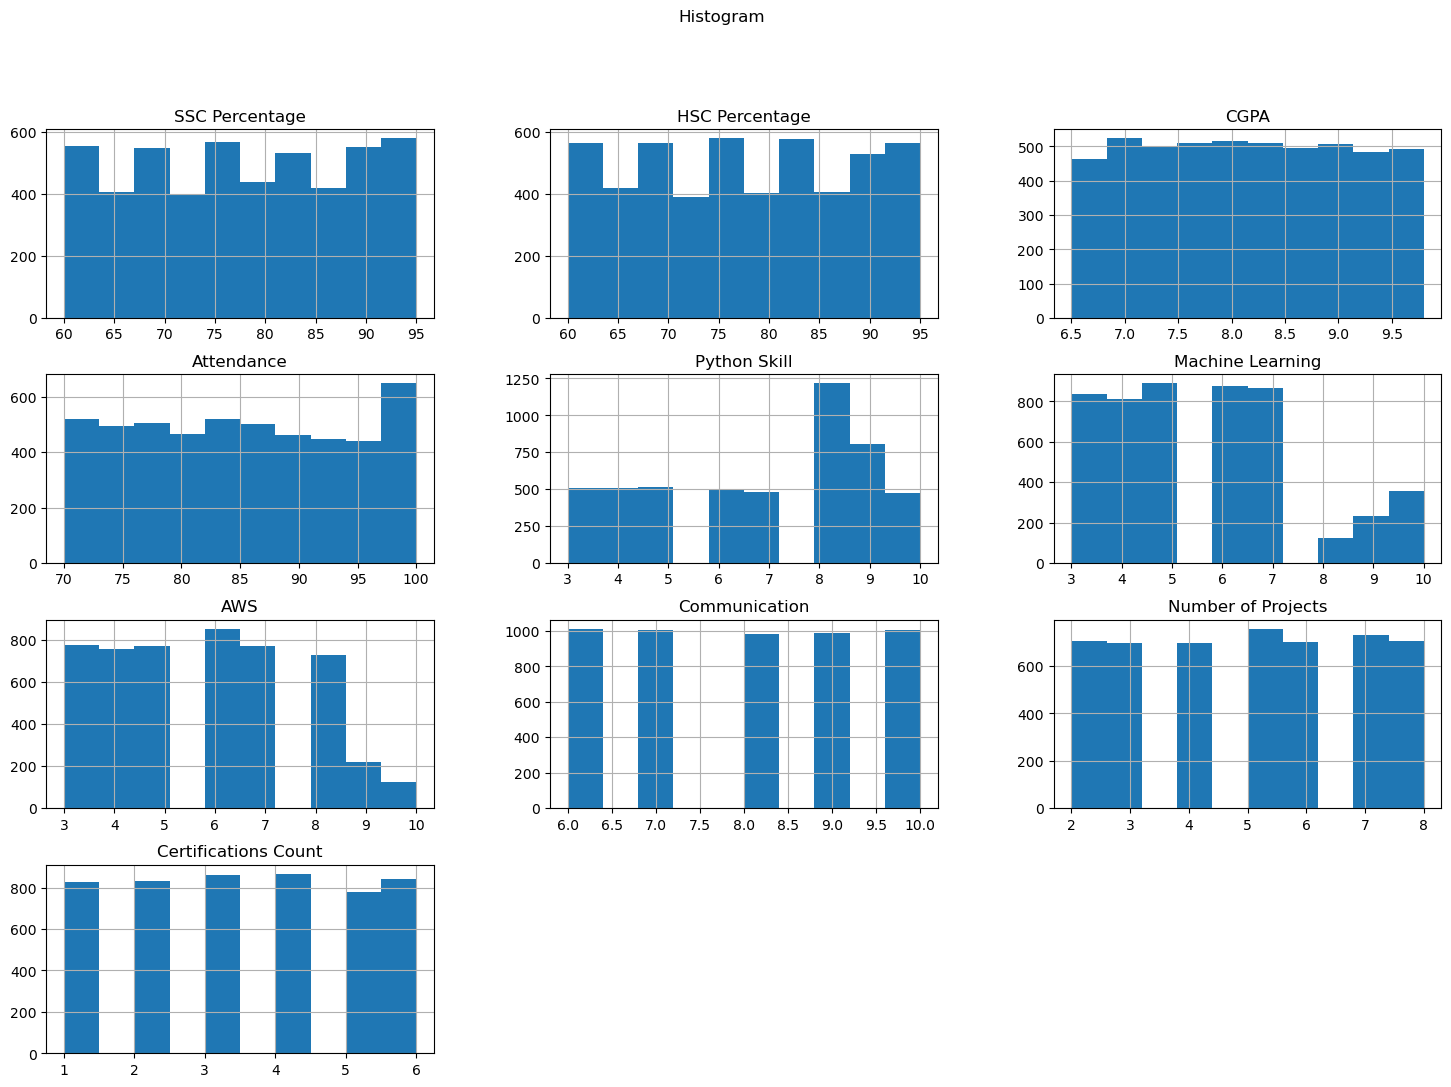

In [14]:
hist_features=[
'SSC Percentage',
'HSC Percentage',
'CGPA',
'Attendance',
'Python Skill',
'Machine Learning',
'AWS',
'Communication',
'Number of Projects',
'Certifications Count'
]

df[hist_features].hist(figsize=(18,12))

plt.suptitle("Histogram")
plt.show()

### Box Plot

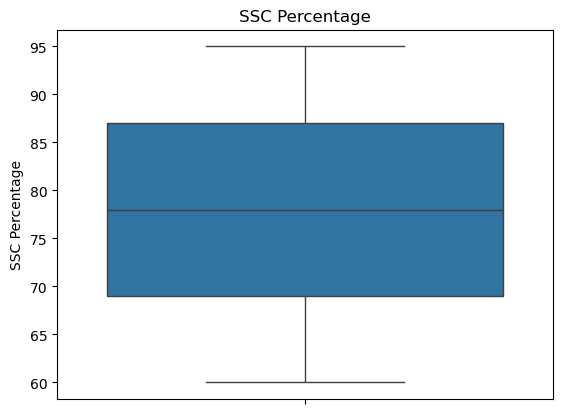

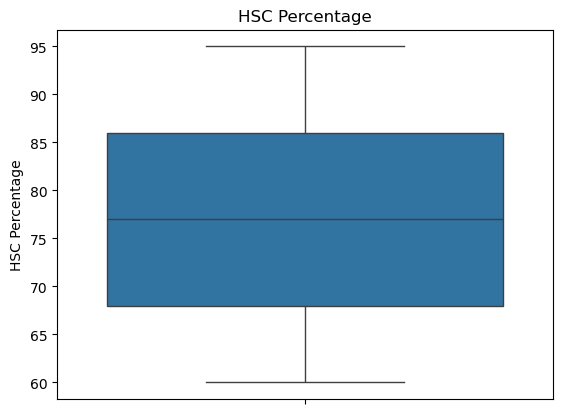

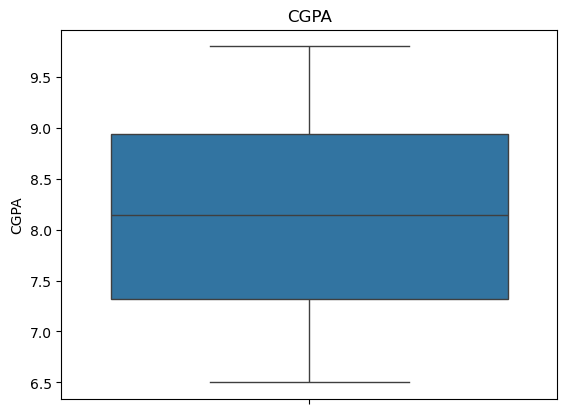

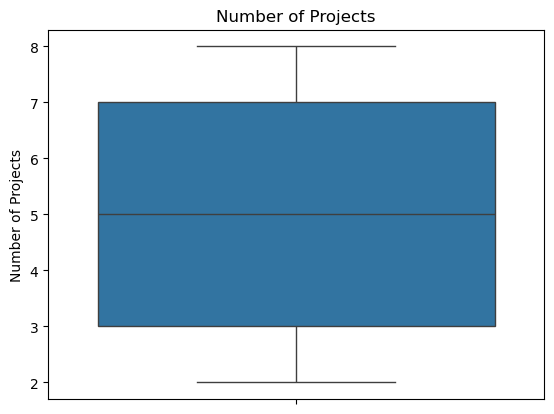

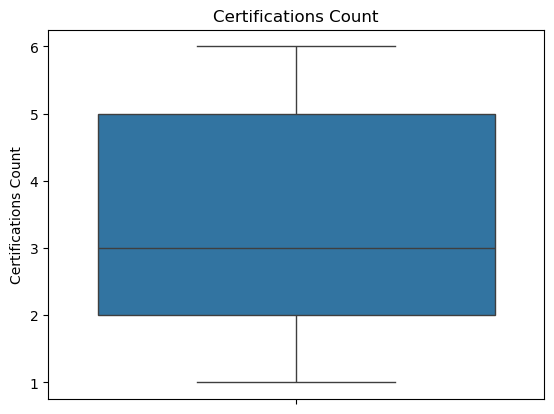

In [15]:
sns.boxplot(y=df["SSC Percentage"])
plt.title("SSC Percentage")
plt.show()

sns.boxplot(y=df["HSC Percentage"])
plt.title("HSC Percentage")
plt.show()

sns.boxplot(y=df["CGPA"])
plt.title("CGPA")
plt.show()

sns.boxplot(y=df["Number of Projects"])
plt.title("Number of Projects")
plt.show()

sns.boxplot(y=df["Certifications Count"])
plt.title("Certifications Count")
plt.show()


# BIVARIATE ANALYSIS

## Scatter Plot

### show the relationship (correlation) between two numerical variables.

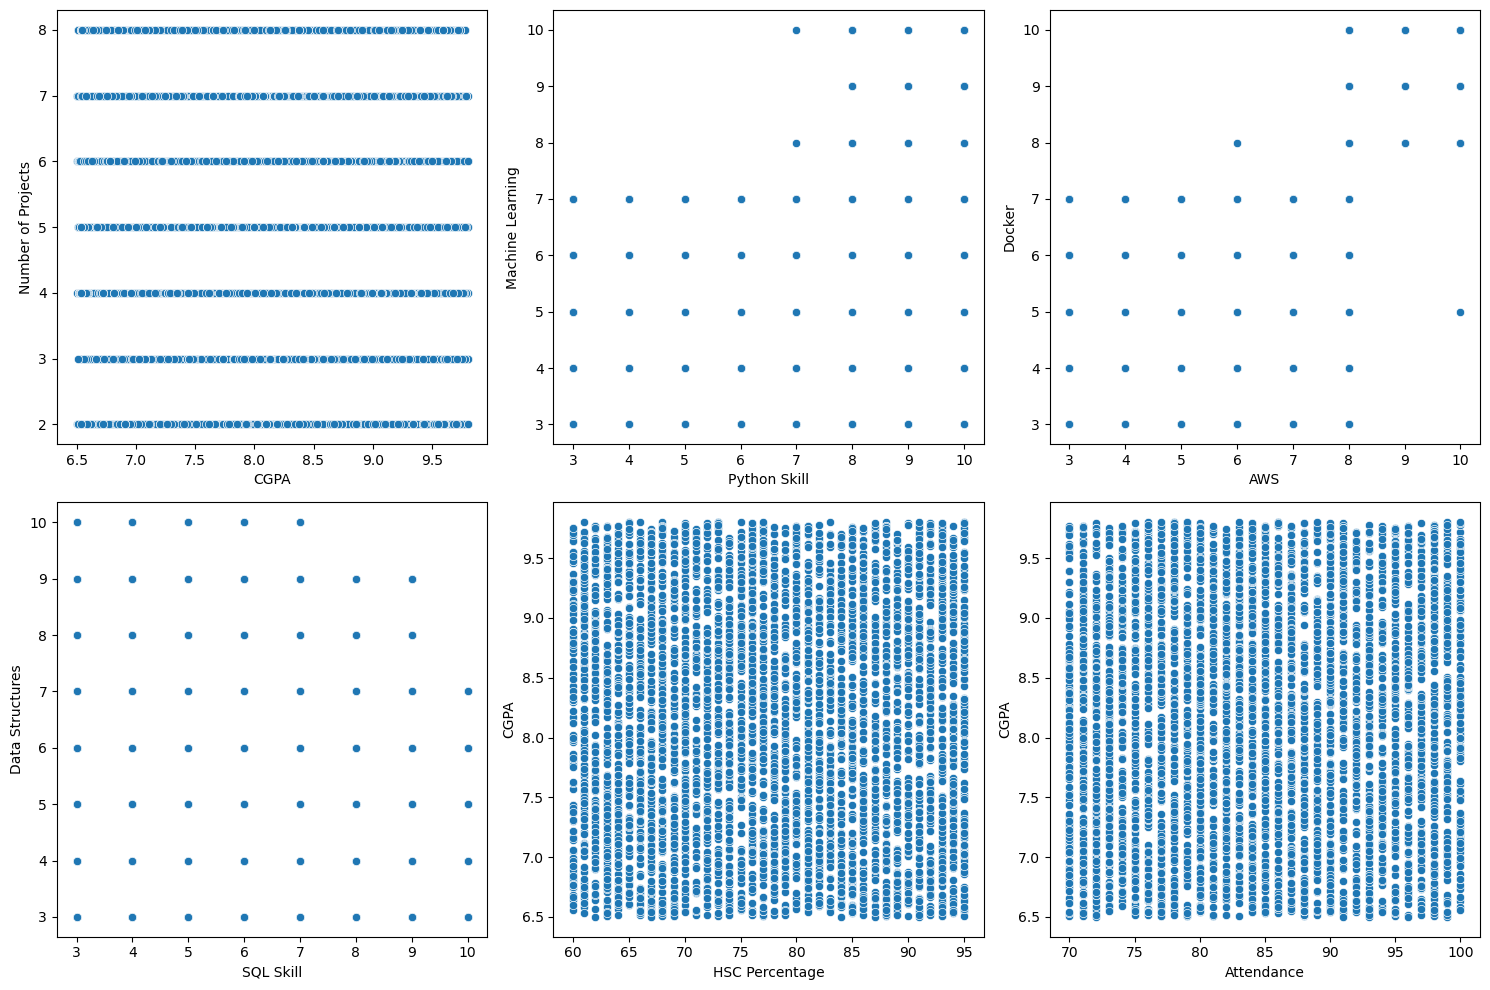

In [16]:
plt.figure(figsize=(15,10))

plt.subplot(2,3,1)
sns.scatterplot(x='CGPA',y='Number of Projects',data=df)

plt.subplot(2,3,2)
sns.scatterplot(x='Python Skill',y='Machine Learning',data=df)

plt.subplot(2,3,3)
sns.scatterplot(x='AWS',y='Docker',data=df)

plt.subplot(2,3,4)
sns.scatterplot(x='SQL Skill',y='Data Structures',data=df)

plt.subplot(2,3,5)
sns.scatterplot(x='HSC Percentage',y='CGPA',data=df)

plt.subplot(2,3,6)
sns.scatterplot(x='Attendance',y='CGPA',data=df)

plt.tight_layout()

plt.show()

## Count Plot
### show the frequency (count) of each category in a categorical variable.

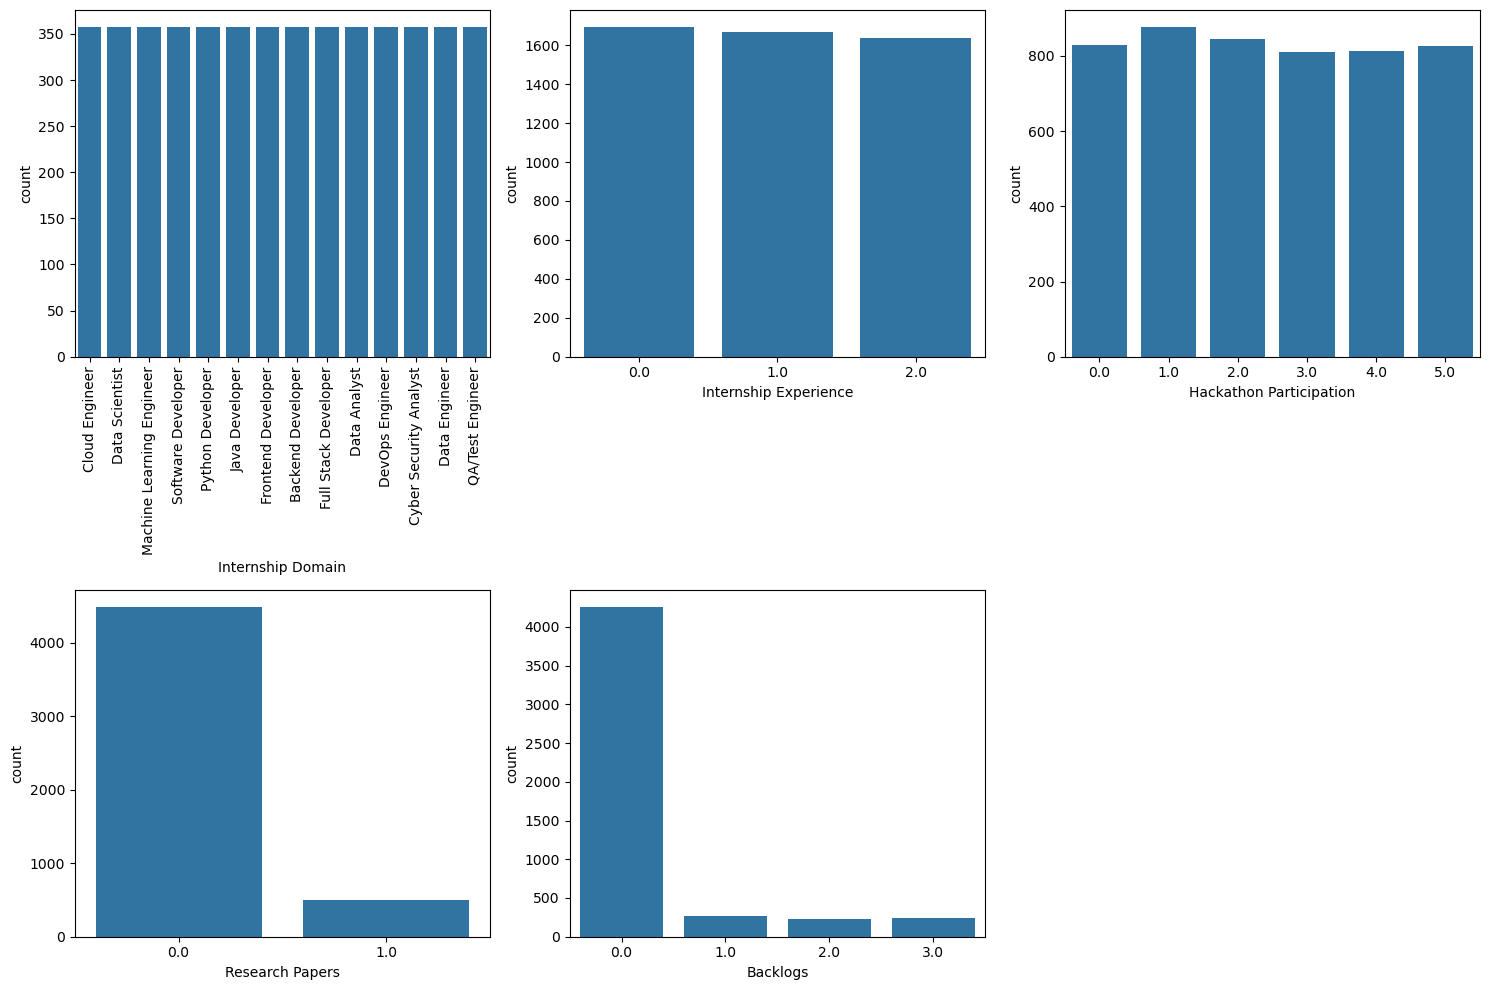

In [17]:
plt.figure(figsize=(15,10))

plt.subplot(2,3,1)
sns.countplot(x='Internship Domain',data=df)
plt.xticks(rotation=90)

plt.subplot(2,3,2)
sns.countplot(x='Internship Experience',data=df)

plt.subplot(2,3,3)
sns.countplot(x='Hackathon Participation',data=df)

plt.subplot(2,3,4)
sns.countplot(x='Research Papers',data=df)

plt.subplot(2,3,5)
sns.countplot(x='Backlogs',data=df)

plt.tight_layout()

plt.show()

# Violin Plot
### A Violin Plot combines the features of a Box Plot and a Density Plot. It shows:


##### The distribution of data
##### The median of the data
##### The spread (variability) of the data
##### The density (where values are concentrated)
##### Possible outliers (depending on settings)

## IT SHOWS

##### 1. Internship Domain vs Machine Learning
##### 2. Internship Domain vs AWS
##### 3. Internship Domain vs Number of Projects
##### 4. Internship Domain vs Certifications Count


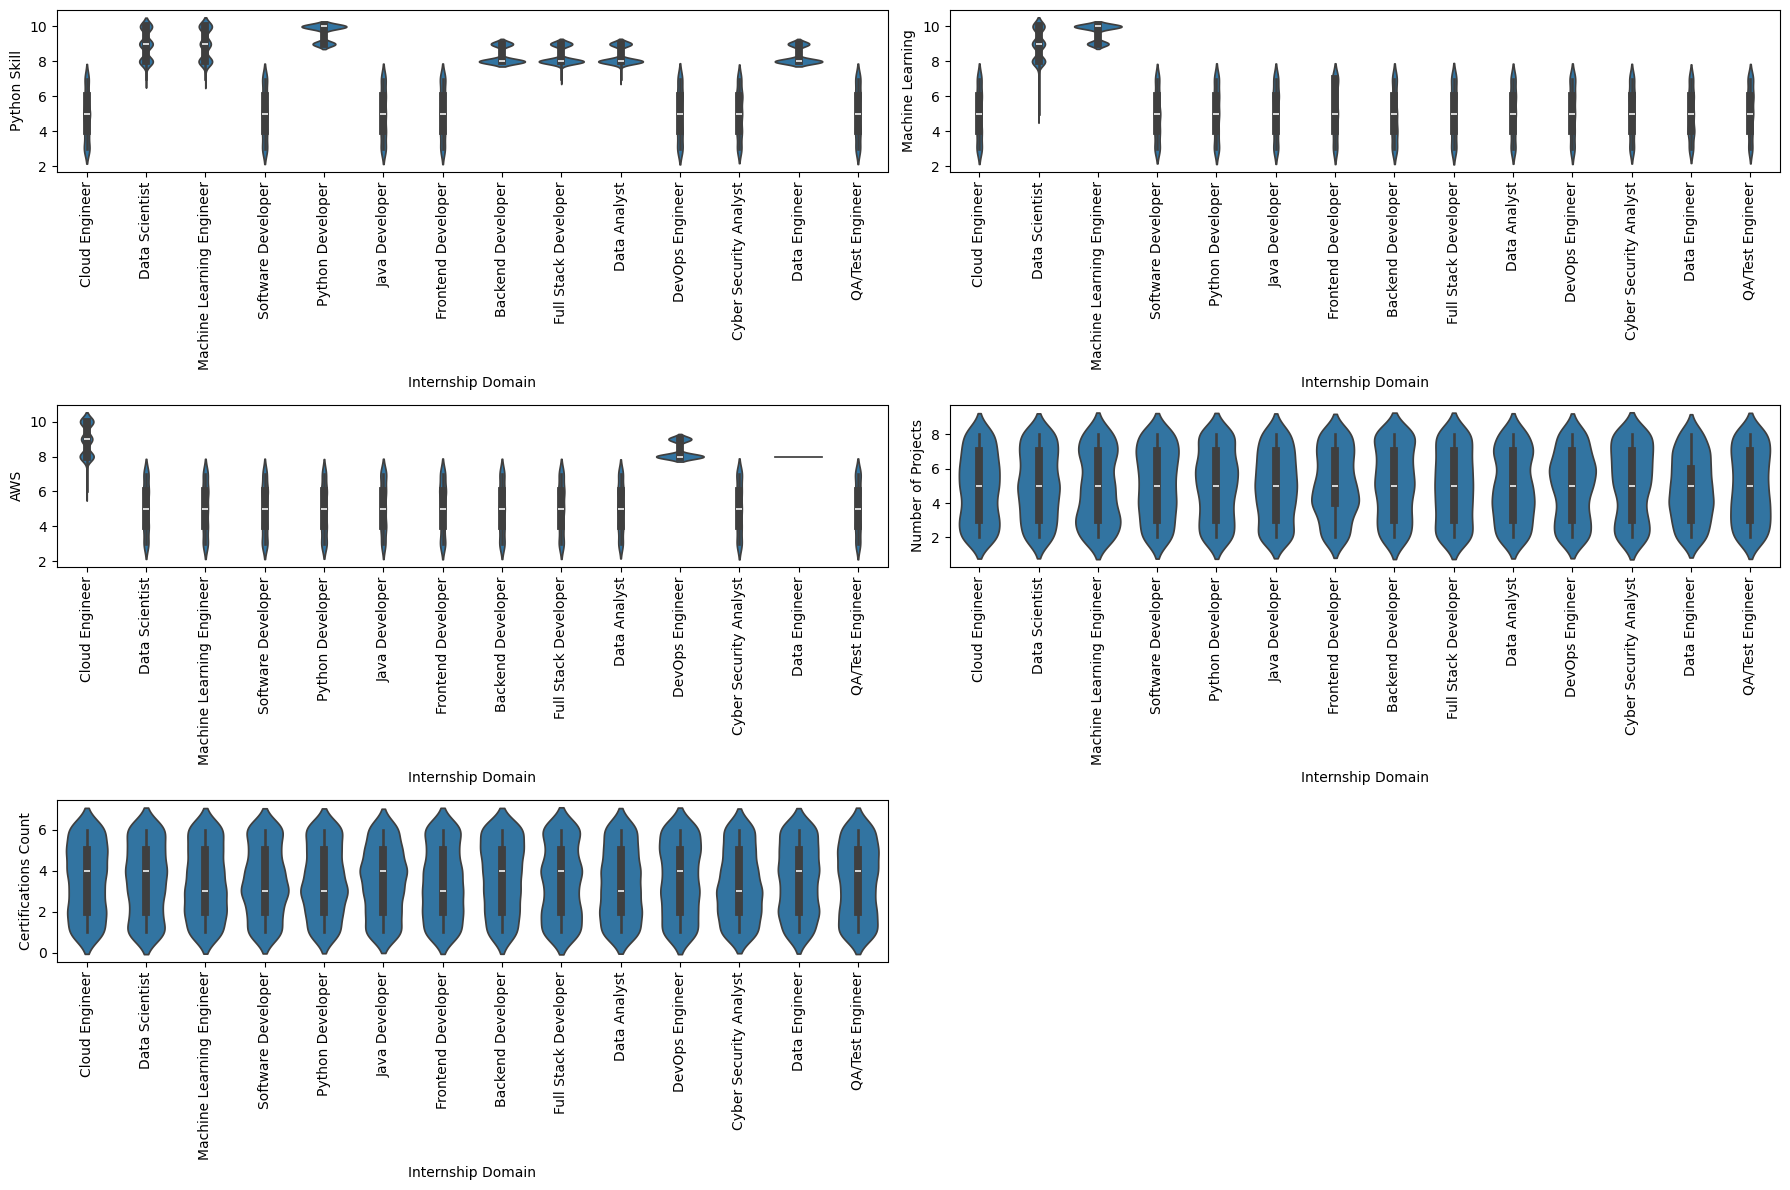

In [18]:
plt.figure(figsize=(18,12))

plt.subplot(3,2,1)
sns.violinplot(x='Internship Domain',
               y='Python Skill',
               data=df)
plt.xticks(rotation=90)

plt.subplot(3,2,2)
sns.violinplot(x='Internship Domain',
               y='Machine Learning',
               data=df)
plt.xticks(rotation=90)

plt.subplot(3,2,3)
sns.violinplot(x='Internship Domain',
               y='AWS',
               data=df)
plt.xticks(rotation=90)

plt.subplot(3,2,4)
sns.violinplot(x='Internship Domain',
               y='Number of Projects',
               data=df)
plt.xticks(rotation=90)

plt.subplot(3,2,5)
sns.violinplot(x='Internship Domain',
               y='Certifications Count',
               data=df)
plt.xticks(rotation=90)

plt.tight_layout()

plt.show()

# MULTIVARIATE ANALYSIS

### Correlation Heatmap

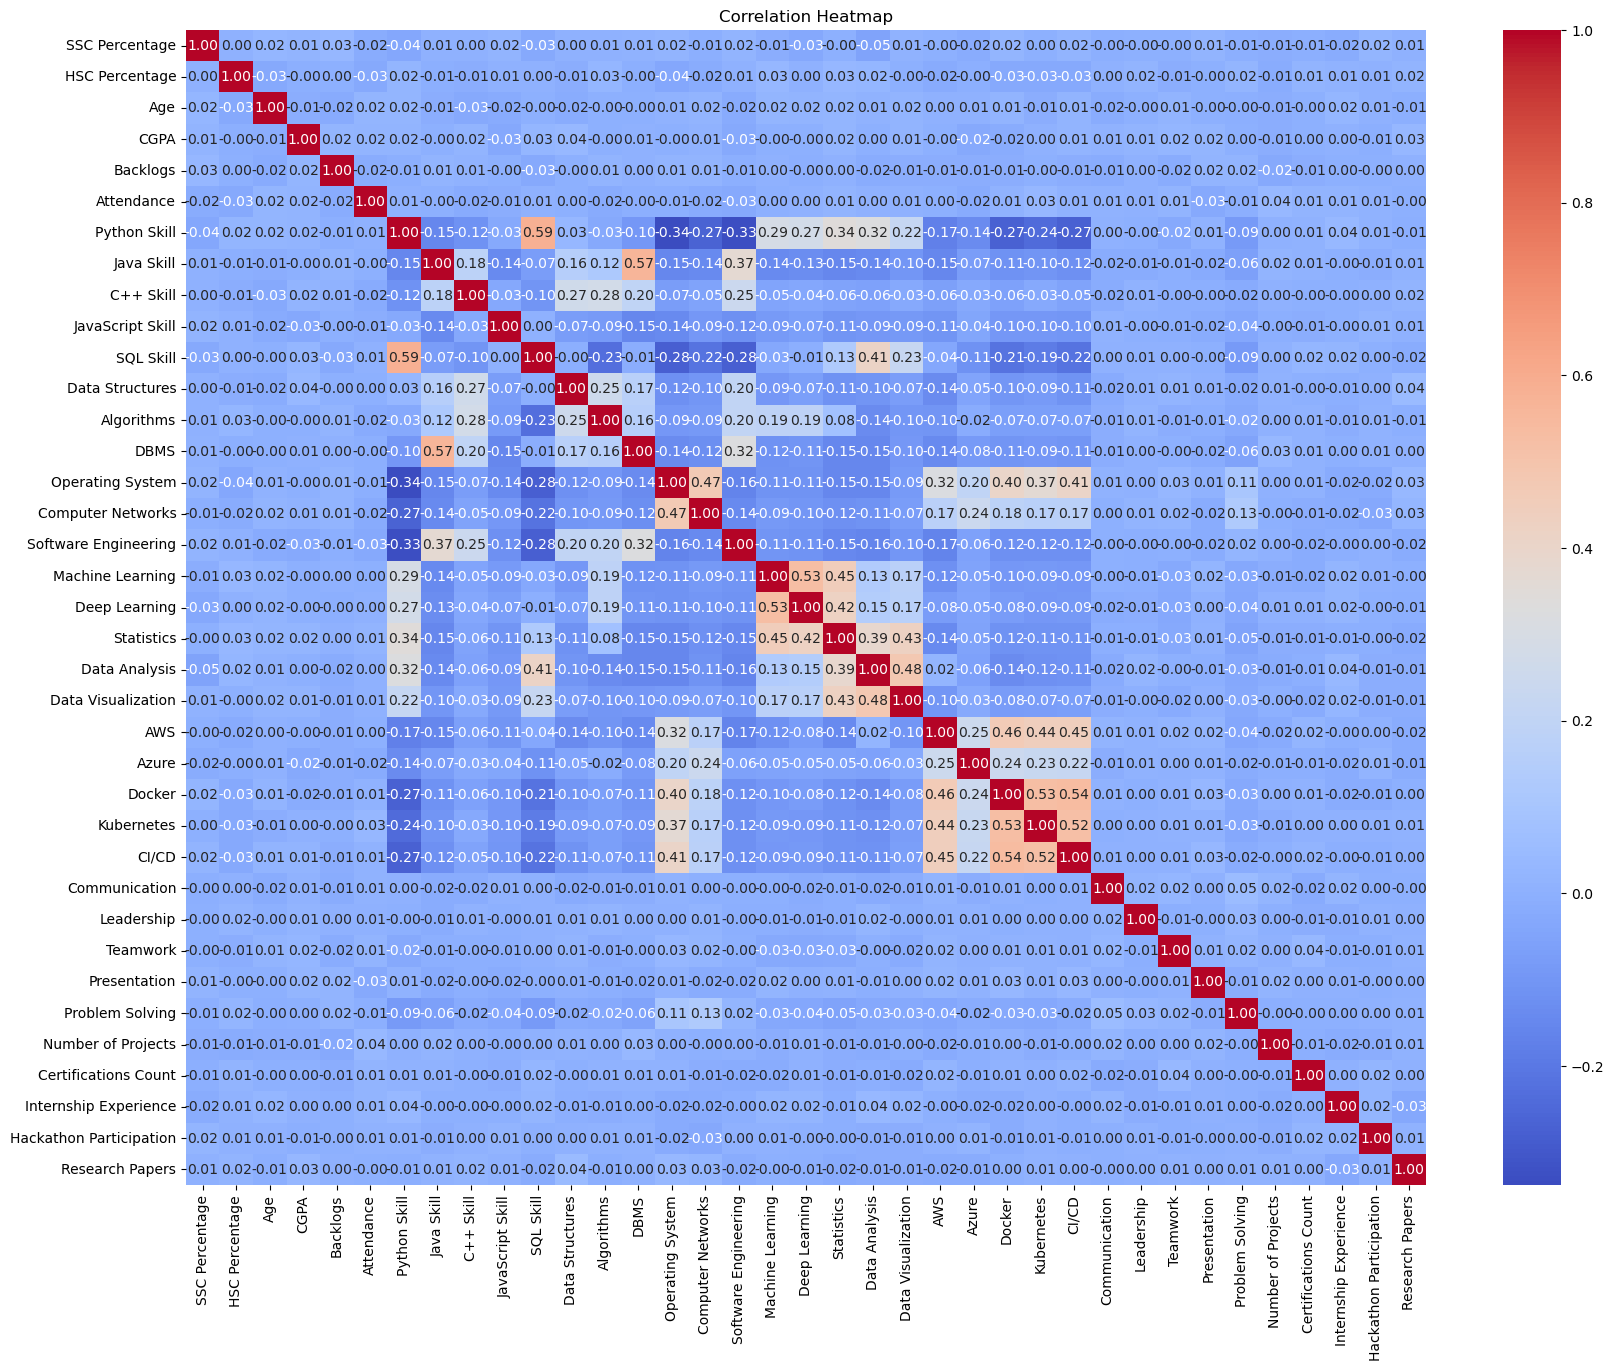

In [19]:
plt.figure(figsize=(20,15))

corr=df.select_dtypes(include=['int64','float64']).corr()

sns.heatmap(corr,
            annot=True,
            cmap='coolwarm',
            fmt=".2f")

plt.title("Correlation Heatmap")

plt.show()

In [20]:
df.dtypes


SSC Percentage             float64
HSC Percentage             float64
Gender                      object
Age                        float64
CGPA                       float64
Backlogs                   float64
Attendance                 float64
Python Skill               float64
Java Skill                 float64
C++ Skill                  float64
JavaScript Skill           float64
SQL Skill                  float64
Data Structures            float64
Algorithms                 float64
DBMS                       float64
Operating System           float64
Computer Networks          float64
Software Engineering       float64
Machine Learning           float64
Deep Learning              float64
Statistics                 float64
Data Analysis              float64
Data Visualization         float64
AWS                        float64
Azure                      float64
Docker                     float64
Kubernetes                 float64
CI/CD                      float64
Communication       

# Encoding

In [21]:
le = LabelEncoder()

df["Internship Domain"] = le.fit_transform(df["Internship Domain"])
df["Gender"] = le.fit_transform(df["Gender"])

In [22]:
df.dtypes

SSC Percentage             float64
HSC Percentage             float64
Gender                       int64
Age                        float64
CGPA                       float64
Backlogs                   float64
Attendance                 float64
Python Skill               float64
Java Skill                 float64
C++ Skill                  float64
JavaScript Skill           float64
SQL Skill                  float64
Data Structures            float64
Algorithms                 float64
DBMS                       float64
Operating System           float64
Computer Networks          float64
Software Engineering       float64
Machine Learning           float64
Deep Learning              float64
Statistics                 float64
Data Analysis              float64
Data Visualization         float64
AWS                        float64
Azure                      float64
Docker                     float64
Kubernetes                 float64
CI/CD                      float64
Communication       

In [23]:
df.isnull().sum()

SSC Percentage             0
HSC Percentage             0
Gender                     0
Age                        0
CGPA                       0
Backlogs                   0
Attendance                 0
Python Skill               0
Java Skill                 0
C++ Skill                  0
JavaScript Skill           0
SQL Skill                  0
Data Structures            0
Algorithms                 0
DBMS                       0
Operating System           0
Computer Networks          0
Software Engineering       0
Machine Learning           0
Deep Learning              0
Statistics                 0
Data Analysis              0
Data Visualization         0
AWS                        0
Azure                      0
Docker                     0
Kubernetes                 0
CI/CD                      0
Communication              0
Leadership                 0
Teamwork                   0
Presentation               0
Problem Solving            0
Number of Projects         0
Certifications

In [24]:
df.columns

Index(['SSC Percentage', 'HSC Percentage', 'Gender', 'Age', 'CGPA', 'Backlogs',
       'Attendance', 'Python Skill', 'Java Skill', 'C++ Skill',
       'JavaScript Skill', 'SQL Skill', 'Data Structures', 'Algorithms',
       'DBMS', 'Operating System', 'Computer Networks', 'Software Engineering',
       'Machine Learning', 'Deep Learning', 'Statistics', 'Data Analysis',
       'Data Visualization', 'AWS', 'Azure', 'Docker', 'Kubernetes', 'CI/CD',
       'Communication', 'Leadership', 'Teamwork', 'Presentation',
       'Problem Solving', 'Number of Projects', 'Certifications Count',
       'Internship Experience', 'Hackathon Participation', 'Research Papers',
       'Internship Domain'],
      dtype='object')

# Feature Selection 

## Select X and Y 

In [25]:
X=df.drop(['Attendance','Internship Domain'],axis=1)
Y=df['Internship Domain']

# train test split 

#### 80% => training data
#### 20% => testing data

In [26]:
print(X.columns)
print(Y)

Index(['SSC Percentage', 'HSC Percentage', 'Gender', 'Age', 'CGPA', 'Backlogs',
       'Python Skill', 'Java Skill', 'C++ Skill', 'JavaScript Skill',
       'SQL Skill', 'Data Structures', 'Algorithms', 'DBMS',
       'Operating System', 'Computer Networks', 'Software Engineering',
       'Machine Learning', 'Deep Learning', 'Statistics', 'Data Analysis',
       'Data Visualization', 'AWS', 'Azure', 'Docker', 'Kubernetes', 'CI/CD',
       'Communication', 'Leadership', 'Teamwork', 'Presentation',
       'Problem Solving', 'Number of Projects', 'Certifications Count',
       'Internship Experience', 'Hackathon Participation', 'Research Papers'],
      dtype='object')
0        1
1        1
2        1
3        1
4        1
        ..
4994    12
4995    12
4996    12
4997    12
5006     1
Name: Internship Domain, Length: 4999, dtype: int64


In [27]:
x_train,x_test,y_train,y_test=train_test_split(X,Y,test_size=0.2,random_state=500)

In [28]:
print(x_train.shape)
x_train.isnull().sum()

(3999, 37)


SSC Percentage             0
HSC Percentage             0
Gender                     0
Age                        0
CGPA                       0
Backlogs                   0
Python Skill               0
Java Skill                 0
C++ Skill                  0
JavaScript Skill           0
SQL Skill                  0
Data Structures            0
Algorithms                 0
DBMS                       0
Operating System           0
Computer Networks          0
Software Engineering       0
Machine Learning           0
Deep Learning              0
Statistics                 0
Data Analysis              0
Data Visualization         0
AWS                        0
Azure                      0
Docker                     0
Kubernetes                 0
CI/CD                      0
Communication              0
Leadership                 0
Teamwork                   0
Presentation               0
Problem Solving            0
Number of Projects         0
Certifications Count       0
Internship Exp

In [29]:
print(x_test.shape)

(1000, 37)


In [30]:
print(y_train.shape)
print(y_test.shape)

(3999,)
(1000,)


# StandardScaler

In [31]:
scaler = StandardScaler()

X_train = scaler.fit_transform(x_train)

X_test = scaler.transform(x_test)

In [32]:
import numpy as np

print(np.isnan(X_train).sum())
print(np.isnan(X_test).sum())

0
0


# Model Training
## 1) Logistic Regression

In [33]:
lr = LogisticRegression(max_iter=1000, random_state=42)
lr.fit(X_train, y_train)

y_pred_lr = lr.predict(X_test)

## 2) Random Forest

In [34]:
rf = RandomForestClassifier(
    n_estimators=100,
    random_state=42
)

rf.fit(X_train, y_train)

y_pred_rf = rf.predict(X_test)

## 3) K-Nearest Neighbors (KNN)

In [35]:
knn = KNeighborsClassifier(n_neighbors=5)

knn.fit(X_train, y_train)

y_pred_knn = knn.predict(X_test)

## 4) Support Vector Machine (SVM)

In [36]:
svm = SVC(kernel='rbf', random_state=42)

svm.fit(X_train, y_train)

y_pred_svm = svm.predict(X_test)

# Model Evaluation

In [37]:

# Logistic Regression
print("Logistic Regression")
print("Accuracy :", accuracy_score(y_test, y_pred_lr))
print("Precision :", precision_score(y_test, y_pred_lr, average='weighted'))
print("Recall :", recall_score(y_test, y_pred_lr, average='weighted'))
print("F1 Score :", f1_score(y_test, y_pred_lr, average='weighted'))

# Random Forest
print("Random Forest")
print("Accuracy :", accuracy_score(y_test, y_pred_rf))
print("Precision :", precision_score(y_test, y_pred_rf, average='weighted'))
print("Recall :", recall_score(y_test, y_pred_rf, average='weighted'))
print("F1 Score :", f1_score(y_test, y_pred_rf, average='weighted'))

# KNN
print("K-Nearest Neighbors (KNN)")
print("Accuracy :", accuracy_score(y_test, y_pred_knn))
print("Precision :", precision_score(y_test, y_pred_knn, average='weighted'))
print("Recall :", recall_score(y_test, y_pred_knn, average='weighted'))
print("F1 Score :", f1_score(y_test, y_pred_knn, average='weighted'))

#SVM
print("Support Vector Machine (SVM)")
print("Accuracy :", accuracy_score(y_test, y_pred_svm))
print("Precision :", precision_score(y_test, y_pred_svm, average='weighted'))
print("Recall :", recall_score(y_test, y_pred_svm, average='weighted'))
print("F1 Score :", f1_score(y_test, y_pred_svm, average='weighted'))

Logistic Regression
Accuracy : 0.994
Precision : 0.9942151727894449
Recall : 0.994
F1 Score : 0.9940117703750091
Random Forest
Accuracy : 1.0
Precision : 1.0
Recall : 1.0
F1 Score : 1.0
K-Nearest Neighbors (KNN)
Accuracy : 0.924
Precision : 0.9254184491538606
Recall : 0.924
F1 Score : 0.9236688603884308
Support Vector Machine (SVM)
Accuracy : 0.995
Precision : 0.9951670501030357
Recall : 0.995
F1 Score : 0.9950105654111076


## Confusion Matrix

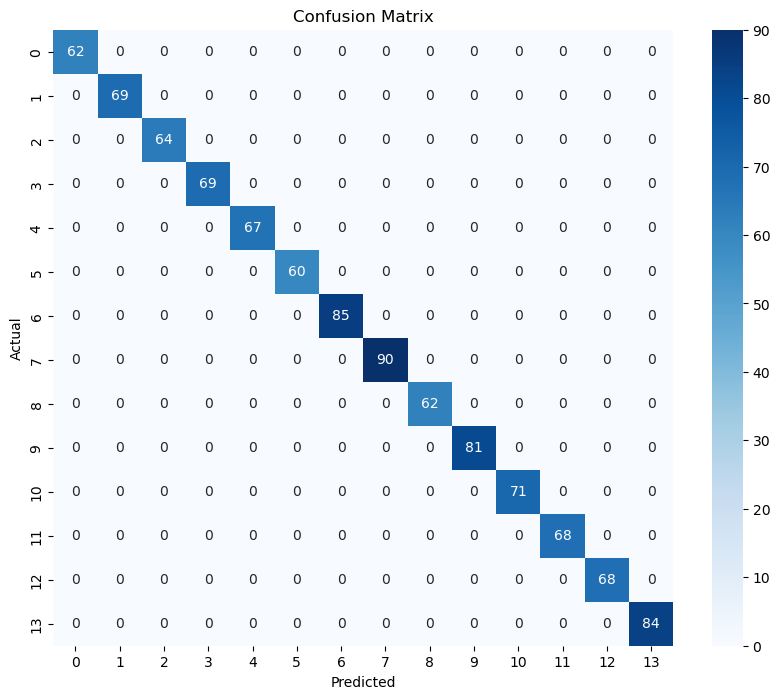

In [38]:
cm = confusion_matrix(y_test, y_pred_rf)

plt.figure(figsize=(10,8))

sns.heatmap(cm,
            annot=True,
            fmt='d',
            cmap='Blues')

plt.xlabel("Predicted")

plt.ylabel("Actual")

plt.title("Confusion Matrix")

plt.show()

## Comparison table

In [39]:
results = pd.DataFrame({
    'Model': [
        'Logistic Regression',
        'Random Forest',
        'KNN',
        'SVM'
    ],

    'Accuracy': [
        accuracy_score(y_test, y_pred_lr),
        accuracy_score(y_test, y_pred_rf),
        accuracy_score(y_test, y_pred_knn),
        accuracy_score(y_test, y_pred_svm)
    ],

    'Precision': [
        precision_score(y_test, y_pred_lr, average='weighted'),
        precision_score(y_test, y_pred_rf, average='weighted'),
        precision_score(y_test, y_pred_knn, average='weighted'),
        precision_score(y_test, y_pred_svm, average='weighted')
    ],

    'Recall': [
        recall_score(y_test, y_pred_lr, average='weighted'),
        recall_score(y_test, y_pred_rf, average='weighted'),
        recall_score(y_test, y_pred_knn, average='weighted'),
        recall_score(y_test, y_pred_svm, average='weighted')
    ],

    'F1 Score': [
        f1_score(y_test, y_pred_lr, average='weighted'),
        f1_score(y_test, y_pred_rf, average='weighted'),
        f1_score(y_test, y_pred_knn, average='weighted'),
        f1_score(y_test,y_pred_svm, average='weighted')
    ]})

print(results)

                 Model  Accuracy  Precision  Recall  F1 Score
0  Logistic Regression     0.994   0.994215   0.994  0.994012
1        Random Forest     1.000   1.000000   1.000  1.000000
2                  KNN     0.924   0.925418   0.924  0.923669
3                  SVM     0.995   0.995167   0.995  0.995011


In [40]:
print("Training Accuracy :", rf.score(X_train, y_train))
print("Testing Accuracy :", rf.score(X_test, y_test))

Training Accuracy : 1.0
Testing Accuracy : 1.0


In [41]:
from sklearn.model_selection import cross_val_score

In [42]:
from sklearn.linear_model import LogisticRegression

lr = LogisticRegression(max_iter=1000, random_state=42)

cv_scores = cross_val_score(
    lr,
    X,
    Y,
    cv=10,
    scoring='accuracy'
)

print("Cross Validation Scores:", cv_scores)
print("Average Accuracy:", cv_scores.mean())
print("Standard Deviation:", cv_scores.std())

c:\ProgramData\anaconda3\Lib\site-packages\sklearn\linear_model\_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(
c:\ProgramData\anaconda3\Lib\site-packages\sklearn\linear_model\_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_

Cross Validation Scores: [1.         0.998      1.         1.         0.99       0.998
 0.996      0.998      0.994      0.99398798]
Average Accuracy: 0.9967987975951903
Standard Deviation: 0.0031251794314774667


c:\ProgramData\anaconda3\Lib\site-packages\sklearn\linear_model\_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


In [43]:
from sklearn.ensemble import RandomForestClassifier

rf = RandomForestClassifier(random_state=42)

cv_scores_rf = cross_val_score(
    rf,
    X,
    Y,
    cv=10,
    scoring='accuracy'
)

print("Average Accuracy:", cv_scores_rf.mean())

Average Accuracy: 0.9996


In [44]:
from sklearn.neighbors import KNeighborsClassifier

knn = KNeighborsClassifier(n_neighbors=5)

cv_scores_knn = cross_val_score(
    knn,
    X,
    Y,
    cv=10,
    scoring='accuracy'
)

print("Average Accuracy:", cv_scores_knn.mean())

Average Accuracy: 0.8881775551102205


In [45]:
from sklearn.svm import SVC

svm = SVC()

cv_scores_svm = cross_val_score(
    svm,
    X,
    Y,
    cv=10,
    scoring='accuracy'
)

print("Average Accuracy:", cv_scores_svm.mean())

Average Accuracy: 0.9795963927855711


In [46]:
import pandas as pd

cv_results = pd.DataFrame({

'Model':[
'Logistic Regression',
'Random Forest',
'KNN',
'SVM'
],

'Cross Validation Accuracy':[

cv_scores.mean(),

cv_scores_rf.mean(),

cv_scores_knn.mean(),

cv_scores_svm.mean()

]

})

cv_results

,Model,Cross Validation Accuracy
0,Logistic Regression,0.996799
1,Random Forest,0.999600
2,KNN,0.888178
3,SVM,0.979596


In [47]:
comparison = pd.DataFrame({
    "Model": ["Logistic Regression", "Random Forest", "KNN", "SVM"],
    "Test Accuracy": [
        accuracy_score(y_test, y_pred_lr),
        accuracy_score(y_test, y_pred_rf),
        accuracy_score(y_test, y_pred_knn),
        accuracy_score(y_test, y_pred_svm)
    ],
    "Cross Validation Accuracy": [
        cv_scores.mean(),
        cv_scores_rf.mean(),
        cv_scores_knn.mean(),
        cv_scores_svm.mean()
    ]
})

comparison["Difference"] = (
    comparison["Test Accuracy"] -
    comparison["Cross Validation Accuracy"]
).abs()

comparison

,Model,Test Accuracy,Cross Validation Accuracy,Difference
0,Logistic Regression,0.994,0.996799,0.002799
1,Random Forest,1.000,0.999600,0.000400
2,KNN,0.924,0.888178,0.035822
3,SVM,0.995,0.979596,0.015404


In [49]:
pip install joblib

Defaulting to user installation because normal site-packages is not writeable
Note: you may need to restart the kernel to use updated packages.


In [52]:
import joblib
joblib.dump(rf, "../model/random_forest_model.pkl")
joblib.dump(scaler, "../model/scaler.pkl")
joblib.dump(le, "../model/label_encoder.pkl")

['../model/label_encoder.pkl']

In [51]:
import os

print(os.listdir())

['InternShip_Recomendation.ipynb']
